In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset from source: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name="MedianHouseValue")

# Train-Test-Split for the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")
X.info()


Dataset loaded: 20640 samples, 8 features.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


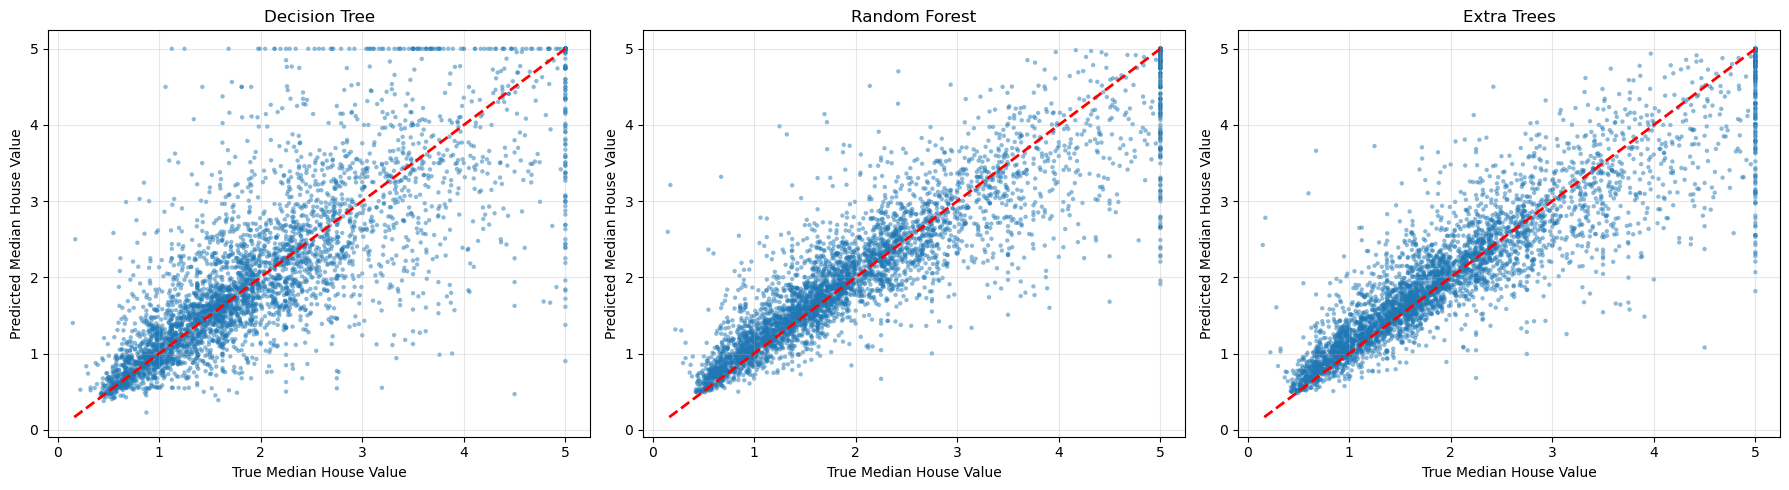

In [16]:
# Initialize Models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Training 
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    # Plot Predicted vs Actual
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, s=10, edgecolors='none')
    
    # Plot a reference line (perfect prediction)
    p1 = max(max(y_pred), max(y_test))
    p2 = min(min(y_pred), min(y_test))
    ax.plot([p1, p2], [p1, p2], 'r--', lw=2)
    
    ax.set_title(f"{name}")
    ax.set_xlabel("True Median House Value")
    ax.set_ylabel("Predicted Median House Value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation of Prediction vs. Ground Truth Plots

The previous plots visualize the relationship between the **true (actual)** median house values and the **values predicted** by three different regression models: a Decision Tree, a Random Forest, and an Extra Trees regressor.

### Axis Description

- **X-axis: True Median House Value**  
  Represents the ground truth values from the test dataset.

- **Y-axis: Predicted Median House Value**  
  Represents the values predicted by the respective model for the same samples.

Each point in the plot corresponds to a single sample (housing district) from the test set.


### Meaning of the Reference Line

The red dashed diagonal line represents the function:
<br> $y = x$

This line indicates **perfect predictions**:
- Points **on the line** correspond to exact predictions.
- Points **above the line** indicate overestimation by the model.
- Points **below the line** indicate underestimation.

The closer the points are clustered around this line, the better the model’s predictive performance.

---

### Model-wise Interpretation

#### Decision Tree Regressor

- The scatter plot shows a wide dispersion of points around the diagonal.
- Predictions appear in vertical bands.
- This behavior indicates **high variance** and a tendency to overfit the training data.

**Conclusion:**  
The Decision Tree struggles to generalize well to unseen data.

---

#### Random Forest Regressor

- Points are tightly clustered around the diagonal line.
- Predictions are smoother and more stable compared to a single tree.
- Variance is significantly reduced through ensemble averaging.

**Conclusion:**  
The Random Forest provides strong generalization performance and accurate predictions.

---

#### Extra Trees Regressor

- The plot is similar to the Random Forest but with slightly more dispersion.
- Additional randomness in split selection increases bias slightly while reducing variance.

**Conclusion:**  
Extra Trees offer a robust and efficient ensemble model with predictive accuracy.

---

### Additional Observations

- All models exhibit increased prediction error for **higher house values**, visible as a widening spread at the upper end of the x-axis.
- This suggests that expensive properties are inherently harder to predict using the available features.
- Overall model quality can be visually assessed by the **thickness of the point cloud** around the diagonal line.

---

### Summary

- **Decision Tree:** High variance, noisy predictions  
- **Random Forest:** Best alignment with true values  
- **Extra Trees:** Strong performance with added randomness


                    MSE      RMSE  R2 Score
Model                                      
Decision Tree  0.499707  0.706900  0.618663
Random Forest  0.255726  0.505694  0.804850
Extra Trees    0.252923  0.502914  0.806989


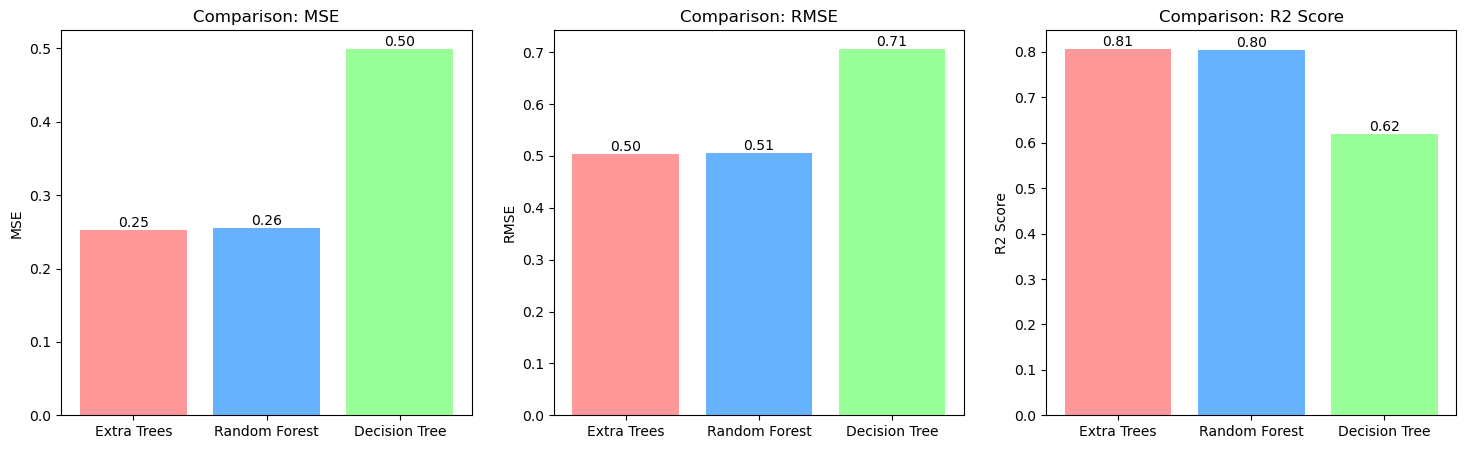

In [18]:
# Plotting Bar charts for evaluation metrics
metrics = ["MSE", "RMSE", "R2 Score"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    ax = axes[i]
    sorted_df = results_df.sort_values(by=metric, ascending=(metric != "R2 Score"))
    
    bars = ax.bar(sorted_df.index, sorted_df[metric], color=['#FF9999', '#66B2FF', '#99FF99'])
    ax.set_title(f"Comparison: {metric}")
    ax.set_ylabel(metric)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

print(results_df)

## Quantitative Performance Comparison

The bar charts above present a numerical comparison of the three models using **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² score**. These results strongly support the visual interpretations from the prediction vs. ground truth plots.

### Error Metrics (MSE and RMSE)

- **Extra Trees** and **Random Forest** achieve similarly low MSE and RMSE values, indicating small average prediction errors.
- The **Decision Tree** shows substantially higher error values, confirming the wider scatter and instability observed in its prediction plot.

These results align with the visual observation that ensemble methods reduce variance and produce more reliable predictions.

---

### Coefficient of Determination (R²)

- **Extra Trees** achieves the highest R² score, closely followed by **Random Forest**, meaning both models explain around 80% of the variance in the target variable.
- The **Decision Tree** exhibits a noticeably lower R² score, reflecting its weaker generalization capability.

This matches the prediction plots, where ensemble models show a tighter alignment with the perfect prediction line.

---

### Overall Interpretation

- The **Decision Tree** suffers from high variance, leading to poorer numerical and visual performance.
- **Random Forest** balances bias and variance effectively, yielding strong and stable results.
- **Extra Trees** slightly outperforms the Random Forest in this case, benefiting from increased randomness and reduced correlation between trees.

Overall, the quantitative metrics confirm the qualitative conclusions drawn from the scatter plots.
